# Data Cleaning and Synthetic Metallicity Injection

This notebook:
- Compares `Ariel_MCS_Known_2024-07-09.csv` and `Ariel_MCS_Known_2025-08-18.csv`
- Verifies how `hermes_synthetic_data.csv` and `hermes_synthetic_data_0.2.0.csv` were produced
- Repeats the same process using the 2025-08-18 file and writes `hermes_synthetic_data_0.3.0.csv`


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd

DATA_2024 = Path('Ariel_MCS_Known_2024-07-09.csv')
DATA_2025 = Path('Ariel_MCS_Known_2025-08-18.csv')
SYN_2024 = Path('hermes_synthetic_data.csv')
SYN_2024_AUG = Path('hermes_synthetic_data_0.2.0.csv')

pd.set_option('display.max_columns', 50)


## Compare 2024 vs 2025 Ariel MCS Known
We compare rows/columns, column set differences, and planets added/removed between the two files.


In [2]:
df24 = pd.read_csv(DATA_2024)
df25 = pd.read_csv(DATA_2025)

print('Rows 2024:', len(df24), 'Rows 2025:', len(df25))
print('Cols 2024:', len(df24.columns), 'Cols 2025:', len(df25.columns))

cols_24_only = sorted(set(df24.columns) - set(df25.columns))
cols_25_only = sorted(set(df25.columns) - set(df24.columns))

print('Columns only in 2024:', cols_24_only)
print('Columns only in 2025:', cols_25_only)

key = 'Planet Name'
set24 = set(df24[key].astype(str))
set25 = set(df25[key].astype(str))
added = sorted(set25 - set24)
removed = sorted(set24 - set25)

print('Added planets:', len(added))
print('Removed planets:', len(removed))
print('Added (sample):', added[:10])
print('Removed (sample):', removed[:10])


Rows 2024: 722 Rows 2025: 814
Cols 2024: 197 Cols 2025: 193
Columns only in 2024: ['Impact Parameter', 'Impact Parameter Error Lower', 'Impact Parameter Error Upper', 'Msin(i) Error Lower [Mj]', 'Msin(i) Error Upper [Mj]', 'Msin(i) [Mj]', 'Transit Mid Time [days]']
Columns only in 2025: ['Msin(i) Error Lower [Mjup]', 'Msin(i) Error Upper [Mjup]', 'Msin(i) [Mjup]']
Added planets: 126
Removed planets: 34
Added (sample): ['GJ238b', 'GJ341b', 'HD101581b', 'HD101581c', 'HD135694b', 'HD235088b', 'HD42813b', 'HIP116454b', 'HIP67522c', 'HIP9618b']
Removed (sample): ['BD-143065b', 'HAT-P-33b', 'HD63433b', 'HD63433c', 'HIP29442b', 'K2-141b', 'K2-31b', 'K2-399b', 'LTT1445Ac', 'NGTS-9b']


## Confirm 2024 synthetic data generation
We verify:
- `logM` equals `log10(Planet Mass [Mjup])` from the 2024 Ariel file
- `log(X_H2O)` follows the reported trend `-1.09 * logM - 0.95` with scatter
- Uncertainty columns are symmetric and equal to 0.2
- `hermes_synthetic_data_0.2.0.csv` is a subset of the synthetic data with added stellar metallicity columns (dropping rows with any missing metallicity values/errors)


In [3]:
syn24 = pd.read_csv(SYN_2024)
mcs24 = pd.read_csv(DATA_2024)

# logM check
logM_expected = np.log10(mcs24.set_index('Planet Name')['Planet Mass [Mjup]'])
logM_check = syn24.set_index('Planet Name')['logM'] - logM_expected.reindex(syn24['Planet Name']).values
print('logM residuals vs log10(Mjup):')
print(logM_check.describe())

# Trend check
trend = -1.09 * syn24['logM'] - 0.95
residuals = syn24['log(X_H2O)'] - trend
print('Trend residuals (log(X_H2O) - trend):')
print(residuals.describe())

# Check fixed uncertainties
print('Unique uncertainty_lower:', syn24['uncertainty_lower'].unique())
print('Unique uncertainty_upper:', syn24['uncertainty_upper'].unique())

# Confirm 0.2.0 augmentation
syn24_aug = pd.read_csv(SYN_2024_AUG)
merge_aug = syn24_aug.merge(mcs24[['Planet Name','Star Metallicity','Star Metallicity Error Lower','Star Metallicity Error Upper']], on='Planet Name', how='left', suffixes=('', '_mcs'))

max_diffs = {}
for col in ['Star Metallicity','Star Metallicity Error Lower','Star Metallicity Error Upper']:
    max_diffs[col] = (merge_aug[col] - merge_aug[col + '_mcs']).abs().max()

print('Max abs diffs for metallicity columns:', max_diffs)
print('Rows in hermes_synthetic_data.csv:', len(syn24))
print('Rows in hermes_synthetic_data_0.2.0.csv:', len(syn24_aug))

missing_any = merge_aug[['Star Metallicity','Star Metallicity Error Lower','Star Metallicity Error Upper']].isna().any(axis=1).sum()
print('Rows in 0.2.0 with any metallicity NA (should be 0):', missing_any)

# Capture residual scatter for reuse
resid_sigma = residuals.std()
print('Residual scatter (std) used to mirror 2024 synthetic generation:', resid_sigma)


logM residuals vs log10(Mjup):
count    7.220000e+02
mean     5.922567e-19
std      6.875541e-17
min     -4.440892e-16
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      4.440892e-16
Name: logM, dtype: float64
Trend residuals (log(X_H2O) - trend):
count    722.000000
mean      -0.021159
std        0.527766
min       -1.487538
25%       -0.381041
50%       -0.019488
75%        0.329874
max        1.395974
dtype: float64
Unique uncertainty_lower: [0.2]
Unique uncertainty_upper: [0.2]
Max abs diffs for metallicity columns: {'Star Metallicity': np.float64(0.0), 'Star Metallicity Error Lower': np.float64(0.0), 'Star Metallicity Error Upper': np.float64(0.0)}
Rows in hermes_synthetic_data.csv: 722
Rows in hermes_synthetic_data_0.2.0.csv: 618
Rows in 0.2.0 with any metallicity NA (should be 0): 0
Residual scatter (std) used to mirror 2024 synthetic generation: 0.5277655299212419


## Create 2025 synthetic data and write `hermes_synthetic_data_0.3.0.csv`
We reproduce the 2024 synthetic recipe using the 2025 file:
- `logM = log10(Planet Mass [Mjup])`
- `log(X_H2O) = -1.09 * logM - 0.95 + N(0, resid_sigma)`
- symmetric uncertainties of 0.2
- add stellar metallicity columns and drop rows with any metallicity NA

A fixed RNG seed is used for reproducibility.


In [4]:
mcs25 = pd.read_csv(DATA_2025)

# Base synthetic (same 5 columns as 2024 synthetic)
logM25 = np.log10(mcs25['Planet Mass [Mjup]'])
rng = np.random.default_rng(42)
noise = rng.normal(0, resid_sigma/5, size=len(mcs25))
logX25 = -1.09 * logM25 - 0.95 + noise

syn25 = pd.DataFrame({
    'Planet Name': mcs25['Planet Name'],
    'logM': logM25,
    'log(X_H2O)': logX25,
    'uncertainty_lower': 0.2,
    'uncertainty_upper': 0.2,
})

# Add stellar metallicity columns and drop rows with any NA in those columns
metal_cols = ['Star Metallicity','Star Metallicity Error Lower','Star Metallicity Error Upper']
syn25_aug = syn25.merge(mcs25[['Planet Name'] + metal_cols], on='Planet Name', how='left')
syn25_aug = syn25_aug.dropna(subset=metal_cols).reset_index(drop=True)

out_path = Path('hermes_synthetic_data_0.5.0.csv')
syn25_aug.to_csv(out_path, index=False)

print('Base synthetic rows (2025):', len(syn25))
print('Rows after metallicity join + NA drop:', len(syn25_aug))
print('Wrote:', out_path.resolve())


Base synthetic rows (2025): 814
Rows after metallicity join + NA drop: 712
Wrote: /Users/wasi/Desktop/HERMES/dataset/hermes_synthetic_data_0.5.0.csv


Added planets (2025 vs 2024): 126
['GJ238b', 'GJ341b', 'HD101581b', 'HD101581c', 'HD135694b', 'HD235088b', 'HD42813b', 'HIP116454b', 'HIP67522c', 'HIP9618b', 'HR858b', 'IRAS04125+2902b', 'K2-18b', 'KOI-7368b', 'Kepler-14b', 'Kepler-25b', 'Kepler-25c', 'L168-9b', 'LHS1140b', 'NGTS-33b', 'Ross176b', 'TIC434398831b', 'TIC434398831c', 'TIC88785435b', 'TOI-1173b', 'TOI-1180b', 'TOI-1184b', 'TOI-1224b', 'TOI-1244b', 'TOI-1248b', 'TOI-1249b', 'TOI-1294b', 'TOI-1410.01', 'TOI-1453c', 'TOI-1472b', 'TOI-1691b', 'TOI-1723b', 'TOI-1758b', 'TOI-1775b', 'TOI-1776b', 'TOI-1794b', 'TOI-1798.01', 'TOI-1803b', 'TOI-1803c', 'TOI-1823b', 'TOI-1836b', 'TOI-1898b', 'TOI-2005b', 'TOI-2031Ab', 'TOI-2107b', 'TOI-2128b', 'TOI-2169Ab', 'TOI-2328b', 'TOI-2346b', 'TOI-2368b', 'TOI-2382b', 'TOI-2407b', 'TOI-260b', 'TOI-2714b', 'TOI-2768b', 'TOI-2876b', 'TOI-2886b', 'TOI-2969b', 'TOI-2981b', 'TOI-2986b', 'TOI-2989b', 'TOI-2992b', 'TOI-3135b', 'TOI-3160Ab', 'TOI-3321b', 'TOI-3464b', 'TOI-3474b', 'TOI-3486b', 'TOI-349

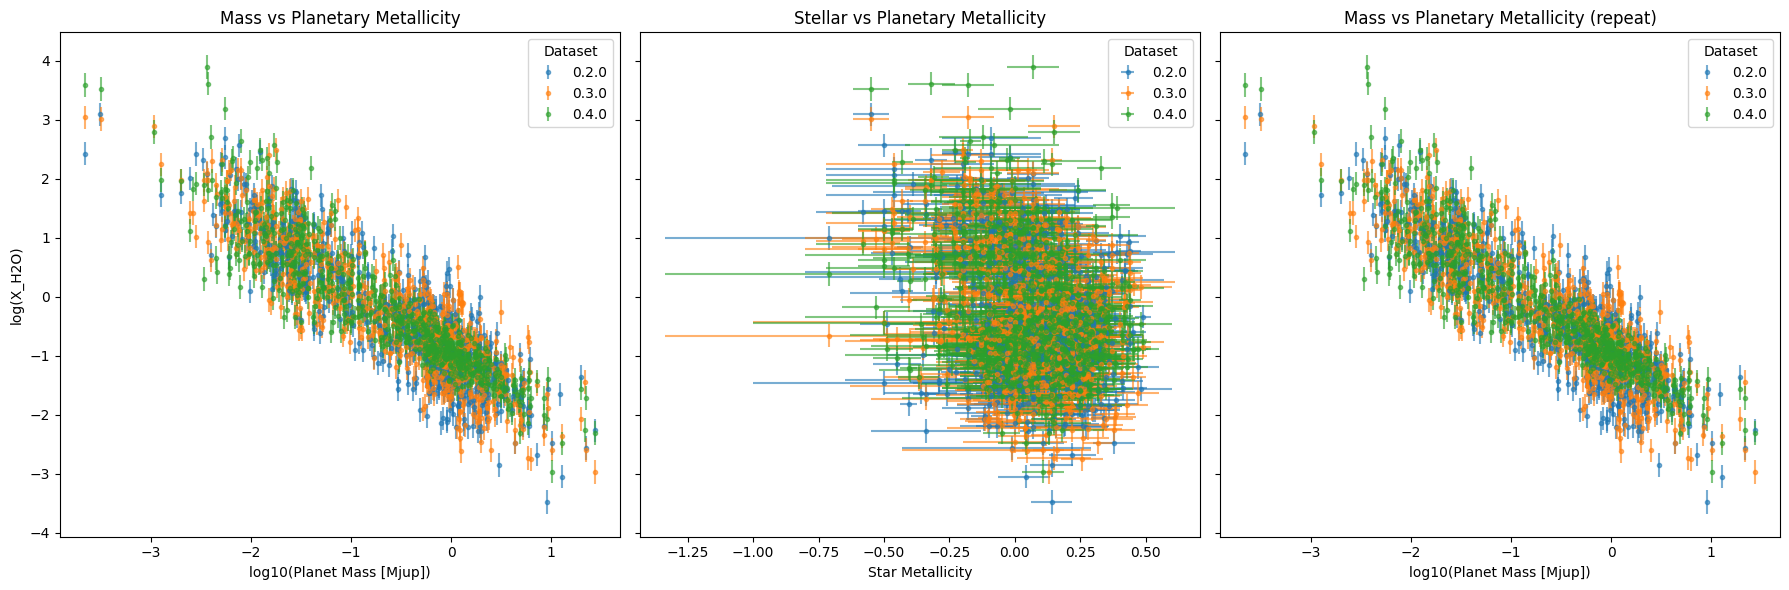

In [6]:
# Added/removed planets (2025 vs 2024) and comparison plots for 0.2.0 vs 0.3.0 vs 0.4.0
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

df24 = pd.read_csv(DATA_2024)
df25 = pd.read_csv(DATA_2025)

set24 = set(df24['Planet Name'].astype(str))
set25 = set(df25['Planet Name'].astype(str))
added = sorted(set25 - set24)
removed = sorted(set24 - set25)

print('Added planets (2025 vs 2024):', len(added))
print(added)
print('Removed planets (2025 vs 2024):', len(removed))
print(removed)

d02 = pd.read_csv('hermes_synthetic_data_0.2.0.csv')
d03 = pd.read_csv('hermes_synthetic_data_0.3.0.csv')
d04 = pd.read_csv('hermes_synthetic_data_0.4.0.csv')

datasets = [
    ('0.2.0', d02, '#1f77b4'),
    ('0.3.0', d03, '#ff7f0e'),
    ('0.4.0', d04, '#2ca02c'),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True)

# Plot 1: Mass vs Planetary Metallicity (with y-uncertainties)
ax = axes[0]
for label, df, color in datasets:
    yerr = np.abs(np.vstack([df['uncertainty_lower'], df['uncertainty_upper']]).astype(float))
    ax.errorbar(
        df['logM'], df['log(X_H2O)'], yerr=yerr,
        fmt='o', ms=3, alpha=0.6, color=color, ecolor=color,
        label=label
    )
ax.set_xlabel('log10(Planet Mass [Mjup])')
ax.set_ylabel('log(X_H2O)')
ax.set_title('Mass vs Planetary Metallicity')
ax.legend(title='Dataset')

# Plot 2: Stellar vs Planetary Metallicity (x/y uncertainties)
ax = axes[1]
for label, df, color in datasets:
    yerr = np.abs(np.vstack([df['uncertainty_lower'], df['uncertainty_upper']]).astype(float))
    xerr = np.abs(np.vstack([df['Star Metallicity Error Lower'], df['Star Metallicity Error Upper']]).astype(float))
    ax.errorbar(
        df['Star Metallicity'], df['log(X_H2O)'], xerr=xerr, yerr=yerr,
        fmt='o', ms=3, alpha=0.6, color=color, ecolor=color,
        label=label
    )
ax.set_xlabel('Star Metallicity')
ax.set_title('Stellar vs Planetary Metallicity')
ax.legend(title='Dataset')

# Plot 3: Mass vs Planetary Metallicity (same data, separate panel for clarity)
ax = axes[2]
for label, df, color in datasets:
    yerr = np.abs(np.vstack([df['uncertainty_lower'], df['uncertainty_upper']]).astype(float))
    ax.errorbar(
        df['logM'], df['log(X_H2O)'], yerr=yerr,
        fmt='o', ms=3, alpha=0.6, color=color, ecolor=color,
        label=label
    )
ax.set_xlabel('log10(Planet Mass [Mjup])')
ax.set_title('Mass vs Planetary Metallicity (repeat)')
ax.legend(title='Dataset')

plt.tight_layout()
plt.show()


Common planets between 0.3.0 and 0.4.0: 712
dlogX = log(X_H2O)_04 - log(X_H2O)_03 summary:
count    712.000000
mean       0.024263
std        0.662859
min       -1.961577
25%       -0.427819
50%        0.012404
75%        0.475279
max        2.118748
Name: dlogX, dtype: float64
logM uncertainty (dex) summary (abs-forced):
       logM_err_low  logM_err_high
count    712.000000     712.000000
mean       0.106004       0.080136
std        0.335281       0.085933
min       -0.365924       0.005389
25%        0.030200       0.028572
50%        0.054849       0.049535
75%        0.110336       0.090177
max        8.497800       0.635718


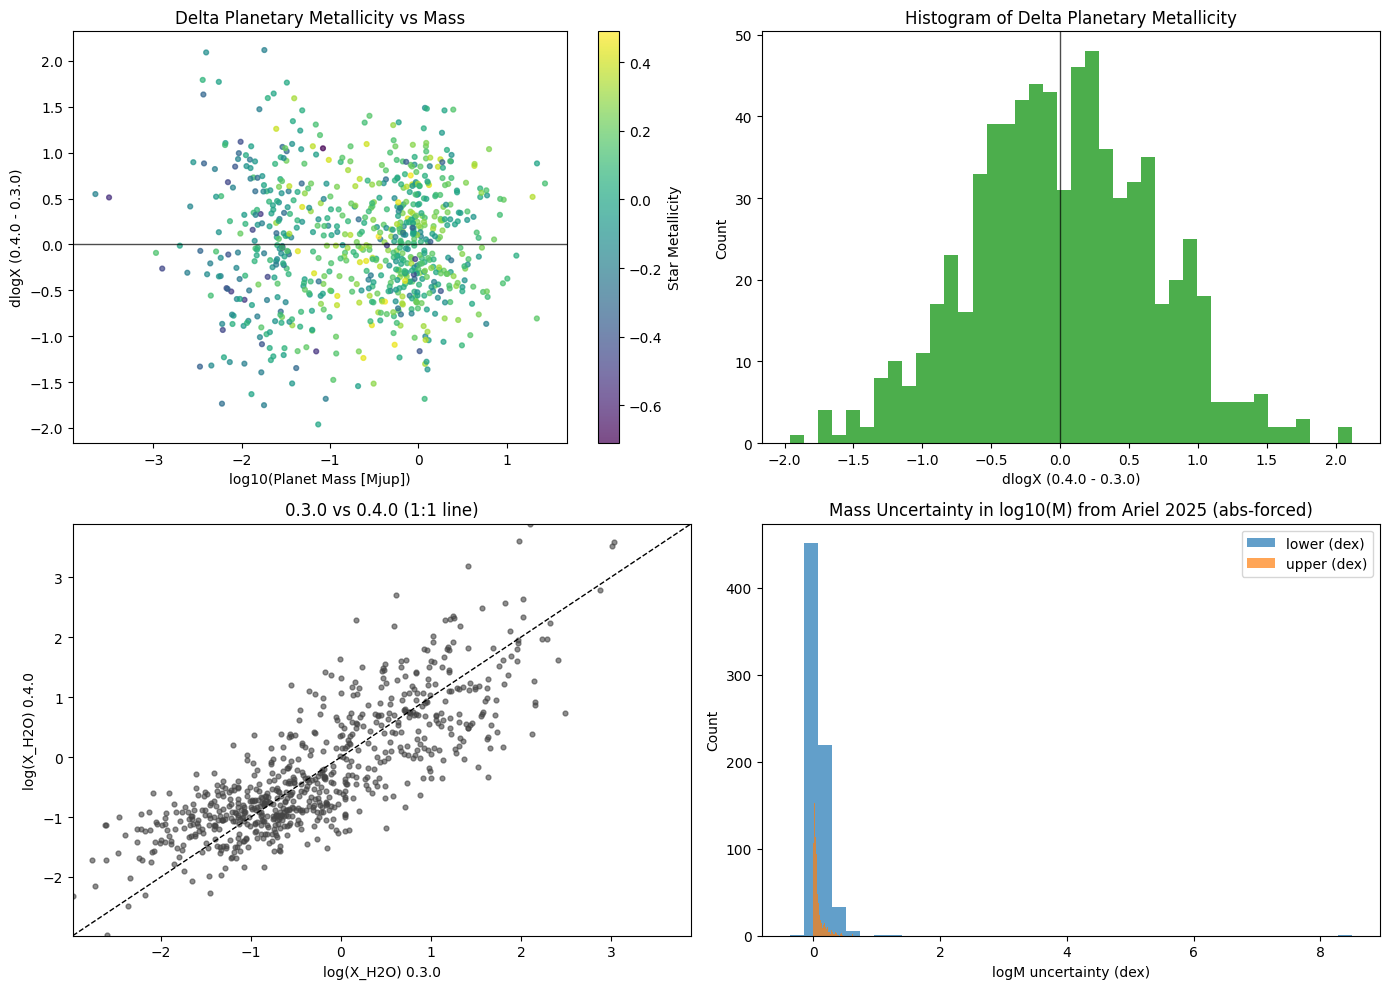

In [7]:
# Difference plots: 0.4.0 - 0.3.0, plus mass-uncertainty diagnostics (from 2025 Ariel)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path

# If already defined earlier in the notebook, this will just reuse it.
DATA_2025 = Path('Ariel_MCS_Known_2025-08-18.csv')

d03 = pd.read_csv('hermes_synthetic_data_0.3.0.csv')
d04 = pd.read_csv('hermes_synthetic_data_0.4.0.csv')
cmp = d03.merge(d04, on='Planet Name', suffixes=('_03', '_04'))

cmp['dlogX'] = cmp['log(X_H2O)_04'] - cmp['log(X_H2O)_03']

print('Common planets between 0.3.0 and 0.4.0:', len(cmp))
print('dlogX = log(X_H2O)_04 - log(X_H2O)_03 summary:')
print(cmp['dlogX'].describe())

# Mass uncertainties from Ariel 2025
# Note: the Ariel file encodes the *lower* error as a negative delta.
# Here we follow your instruction to take abs() so log10-uncertainty plots do not fail
# even when M + dM_low crosses 0 (this is a pragmatic plotting choice).
mcs25 = pd.read_csv(DATA_2025)
m = mcs25.set_index('Planet Name')

M = m.loc[cmp['Planet Name'], 'Planet Mass [Mjup]'].to_numpy(float)
dM_low = m.loc[cmp['Planet Name'], 'Planet Mass Error Lower [Mjup]'].to_numpy(float)
dM_high = m.loc[cmp['Planet Name'], 'Planet Mass Error Upper [Mjup]'].to_numpy(float)

M_low = np.abs(M + dM_low)
M_high = np.abs(M + dM_high)

# avoid log10(0) if abs() produces exactly 0
eps = 1e-12
M_low = np.maximum(M_low, eps)
M_high = np.maximum(M_high, eps)

logM = np.log10(M)
logM_low = np.log10(M_low)
logM_high = np.log10(M_high)
logM_err_low = logM - logM_low
logM_err_high = logM_high - logM

print('logM uncertainty (dex) summary (abs-forced):')
print(pd.DataFrame({'logM_err_low': logM_err_low, 'logM_err_high': logM_err_high}).describe())

# Plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

ax = axes[0, 0]
sc = ax.scatter(
    cmp['logM_03'], cmp['dlogX'],
    s=12, alpha=0.7,
    c=cmp['Star Metallicity_03'], cmap='viridis'
)
ax.axhline(0, color='k', lw=1, alpha=0.7)
ax.set_xlabel('log10(Planet Mass [Mjup])')
ax.set_ylabel('dlogX (0.4.0 - 0.3.0)')
ax.set_title('Delta Planetary Metallicity vs Mass')
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Star Metallicity')

ax = axes[0, 1]
ax.hist(cmp['dlogX'], bins=40, color='#2ca02c', alpha=0.85)
ax.axvline(0, color='k', lw=1, alpha=0.7)
ax.set_xlabel('dlogX (0.4.0 - 0.3.0)')
ax.set_ylabel('Count')
ax.set_title('Histogram of Delta Planetary Metallicity')

ax = axes[1, 0]
ax.scatter(cmp['log(X_H2O)_03'], cmp['log(X_H2O)_04'], s=12, alpha=0.6, color='#444444')
lims = [
    min(cmp['log(X_H2O)_03'].min(), cmp['log(X_H2O)_04'].min()),
    max(cmp['log(X_H2O)_03'].max(), cmp['log(X_H2O)_04'].max()),
]
ax.plot(lims, lims, 'k--', lw=1)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel('log(X_H2O) 0.3.0')
ax.set_ylabel('log(X_H2O) 0.4.0')
ax.set_title('0.3.0 vs 0.4.0 (1:1 line)')

ax = axes[1, 1]
ax.hist(logM_err_low, bins=40, alpha=0.7, label='lower (dex)', color='#1f77b4')
ax.hist(logM_err_high, bins=40, alpha=0.7, label='upper (dex)', color='#ff7f0e')
ax.set_xlabel('logM uncertainty (dex)')
ax.set_ylabel('Count')
ax.set_title('Mass Uncertainty in log10(M) from Ariel 2025 (abs-forced)')
ax.legend()

plt.tight_layout()
plt.show()
